In [ ]:
import nci_ipynb
import os
os.environ["EARTHKIT_DATA_CACHE_POLICY"] = "off"

nb_path = nci_ipynb.dir()
os.chdir(nb_path)

# Hands-on: Run an Anemoi Model


This notebook describes how to run inference from an existing checkpoint. This provides a step by step use from the notebook, it is also possible to run from the command line. See the `command_line.md` for more info on that.


**Resources:**

[anemoi-inference](https://anemoi-inference.readthedocs.io/en/latest/apis/level1.html) package.

In [2]:
from pathlib import Path
import subprocess
import torch
import warnings
import copy
warnings.filterwarnings("ignore", category=UserWarning)


In [3]:
from anemoi.inference.checkpoint import Checkpoint
from anemoi.inference.runners.simple import SimpleRunner
from anemoi.inference.outputs.printer import print_state

from helpers import find_nearest_point_index

## Investigate the checkpoint

For that we first set the path to the checkpoint, this can one you trained, accessible at `/scratch/$PROJECT/$USER/anemoi-output/checkpoint/RUN_ID/inference-last.ckpt`, or one pretrained for you at `/g/data/dk92/data/anemoi/inference-single.ckpt`.

In [ ]:
ckpt_file = PATH_HERE

The checkpoint contains all the relevant information about the model and the required input.

In [5]:
print("Loading checkpoint...")
ckpt = Checkpoint(ckpt_file)

# Variables used during training:
print("Number of variables:", len(ckpt.variable_categories()))
print(f"Diagnostic variables: {ckpt.select_variables(include=['diagnostic'])}")
print(f"Prognostic variables: {ckpt.select_variables(include=['prognostic'])}")
print(f"Forcing variables: {ckpt.select_variables(include=['forcing'])}")

Loading checkpoint...
Number of variables: 23
Diagnostic variables: ['cp', 'tp']
Prognostic variables: ['2t', 't_850', 'tcw', 'z_1000', 'z_250', 'z_300', 'z_500', 'z_700']
Forcing variables: ['lsm', 'sdor', 'slor', 'z']


The model architecture

In [6]:
model = torch.load(ckpt.path, weights_only=False, map_location="cpu")
model

AnemoiModelInterface(
  (pre_processors): ModuleDict(
    (data): Processors [forward](ModuleDict(
      (normalizer): InputNormalizer()
    ))
  )
  (post_processors): ModuleDict(
    (data): Processors [inverse](ModuleDict(
      (normalizer): InputNormalizer()
    ))
  )
  (pre_processors_tendencies): ModuleDict(
    (data): Processors [forward](ModuleDict(
      (normalizer): InputNormalizer()
    ))
  )
  (post_processors_tendencies): ModuleDict(
    (data): Processors [inverse](ModuleDict(
      (normalizer): InputNormalizer()
    ))
  )
  (model): AnemoiModelEncProcDec(
    (node_attributes): NamedNodesAttributes(
      (trainable_tensors): ModuleDict(
        (data): TrainableTensor()
        (hidden): TrainableTensor()
      )
    )
    (encoder_graph_provider): ModuleDict(
      (data): StaticGraphProvider(
        (trainable): TrainableTensor()
      )
    )
    (encoder): ModuleDict(
      (data): GraphTransformerForwardMapper(
        (activation): GELU(approximate='none')

In [7]:
print(f"Number of weights: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Number of weights: 2562442


## Get initial conditions


Running the model for inference requires initial conditions. We retrieve Initial Conditions from ECMWF Open Data.




In [8]:
import datetime
from collections import defaultdict
from pathlib import Path

import numpy as np
import earthkit.data as ekd
import earthkit.regrid as ekr

from ecmwf.opendata import Client as OpendataClient
from helpers import load_saved_state, save_state

In [9]:
R = 6371.0  # Earth radius in km

# ENSURE THAT THIS IS THE SAME AS IN THE TRAINING CONFIG
GRID_RESOLUTION = "O48"
# PARAM_SFC = ["10u", "10v", "2d", "2t", "msl", "skt", "sp", "tcw", "lsm", "z", "slor", "sdor"]
PARAM_SFC = ['2t', 'tcw', "lsm", "z", "slor", "sdor"]
# PARAM_PL = ["gh", "t", "u", "v", "w", "q"]
PARAM_PL = ['t', 'gh']
# LEVELS = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50]
LEVELS = [1000, 850, 700, 500, 300, 250]

DATE = OpendataClient().latest()
print("Initial date is", DATE)

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


Initial date is 2026-04-13 18:00:00


In [10]:
def get_open_data(param, levelist=[], reference_date=DATE):
    fields = defaultdict(list)
    # Get the data for the current date and the previous date
    for date in [reference_date - datetime.timedelta(hours=6), reference_date]:
        data = ekd.from_source("ecmwf-open-data", date=date, param=param, levelist=levelist)
        for f in data:
            # Open data is between -180 and 180, we need to shift it to 0-360
            assert f.to_numpy().shape == (721, 1440)
            values = np.roll(f.to_numpy(), -f.shape[1] // 2, axis=1)
            # Interpolate the data to from 0.25 to grid
            values = ekr.interpolate(values, {"grid": (0.25, 0.25)}, {"grid": GRID_RESOLUTION})
            # Add the values to the list
            name = f"{f.metadata('param')}_{f.metadata('levelist')}" if levelist else f.metadata("param")
            fields[name].append(values)

    # Create a single matrix for each parameter
    for param, values in fields.items():
        fields[param] = np.stack(values)

    return fields

Here we make a single forecast, from the control initial conditions of the IFS.

In [11]:
file = Path(f"inputstate-{GRID_RESOLUTION}-{DATE.strftime('%Y%m%d_%H')}.npz") # Remove this file if you want to always load from open data, or if you want to save a new state with different parameters
if file.exists():
    input_state = load_saved_state(file)
    print(f"Input state loaded from file {file}")
else:
    fields = {}
    # Surface fields
    fields.update(get_open_data(param=PARAM_SFC, reference_date=DATE))
    # Pressure levels fields
    fields.update(get_open_data(param=PARAM_PL, levelist=LEVELS, reference_date=DATE))

    # Convert geopotential height into geopotential
    for level in LEVELS:
        gh = fields.pop(f"gh_{level}")
        fields[f"z_{level}"] = gh * 9.80665
    
    input_state = dict(date=DATE, fields=fields)

    print(f"State created for date {DATE}")
    save_state(input_state, file)

    print(f"State saved to file {file}")

<multiple>:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


<multiple>:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

<multiple>:   0%|          | 0.00/6.17M [00:00<?, ?B/s]

<multiple>:   0%|          | 0.00/6.18M [00:00<?, ?B/s]

State created for date 2026-04-13 18:00:00
State saved to file inputstate-O48-20260413_18.npz


## Run inference from initial conditions

In [12]:
runner = SimpleRunner(ckpt_file)

# Limit the input state to the variables used by the model
input_state['fields'] = {k: input_state['fields'][k] for k in input_state['fields'].keys() if k in runner.checkpoint.typed_variables}

In [13]:
LEAD_TIME = 48

### Run the forecast



In [14]:
forecast_states = []
for step, state in enumerate(runner.run(input_state=input_state, lead_time=LEAD_TIME)):
    print(f"Step {step}: {state['date']} (lead time: {state['step']})")
    print(f"  Available fields: {list(state['fields'].keys())}")
    # Store the state if you want to keep it
    forecast_states.append(copy.deepcopy(state))

print(f"Forecast completed! Generated {len(forecast_states)} time steps.")

Coupled forcings are not supported by this runner: ['lsm', 'sdor', 'slor', 'z']


Step 0: 2026-04-14 00:00:00 (lead time: 6:00:00)
  Available fields: ['z_1000', 'z_500', 'z_700', 'z_300', '2t', 't_850', 'tcw', 'z_250', 'cp', 'tp']
Step 1: 2026-04-14 06:00:00 (lead time: 12:00:00)
  Available fields: ['z_1000', 'z_500', 'z_700', 'z_300', '2t', 't_850', 'tcw', 'z_250', 'cp', 'tp']
Step 2: 2026-04-14 12:00:00 (lead time: 18:00:00)
  Available fields: ['z_1000', 'z_500', 'z_700', 'z_300', '2t', 't_850', 'tcw', 'z_250', 'cp', 'tp']
Step 3: 2026-04-14 18:00:00 (lead time: 1 day, 0:00:00)
  Available fields: ['z_1000', 'z_500', 'z_700', 'z_300', '2t', 't_850', 'tcw', 'z_250', 'cp', 'tp']
Step 4: 2026-04-15 00:00:00 (lead time: 1 day, 6:00:00)
  Available fields: ['z_1000', 'z_500', 'z_700', 'z_300', '2t', 't_850', 'tcw', 'z_250', 'cp', 'tp']
Step 5: 2026-04-15 06:00:00 (lead time: 1 day, 12:00:00)
  Available fields: ['z_1000', 'z_500', 'z_700', 'z_300', '2t', 't_850', 'tcw', 'z_250', 'cp', 'tp']
Step 6: 2026-04-15 12:00:00 (lead time: 1 day, 18:00:00)
  Available fields:

In [15]:
print(f"Predicted dates: {list(forecast_states[x]['date'].strftime('%Y-%m-%dT%H') for x in range(len(forecast_states)))}")

Predicted dates: ['2026-04-14T00', '2026-04-14T06', '2026-04-14T12', '2026-04-14T18', '2026-04-15T00', '2026-04-15T06', '2026-04-15T12', '2026-04-15T18']


# 4. Inspect the generated forecast

### Plot a field

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.tri as tri

In [17]:
def fix(lons):
    # Shift the longitudes from 0-360 to -180-180
    return np.where(lons > 180, lons - 360, lons)

# pick a state
variable = "tcw"
state = forecast_states[-1]
date = state['date']
latitudes = state["latitudes"]
longitudes = fix(state["longitudes"])
values = state["fields"][variable]

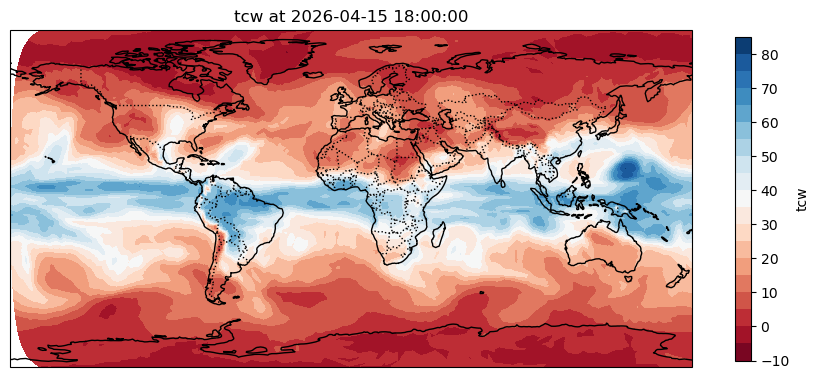

In [18]:
fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

triangulation = tri.Triangulation(fix(longitudes), latitudes)

contour=ax.tricontourf(triangulation, values, levels=20, transform=ccrs.PlateCarree(), cmap="RdBu")
cbar = fig.colorbar(contour, ax=ax, orientation="vertical", shrink=0.7, label=variable)

plt.title("{} at {}".format(variable, state["date"]))
plt.show()


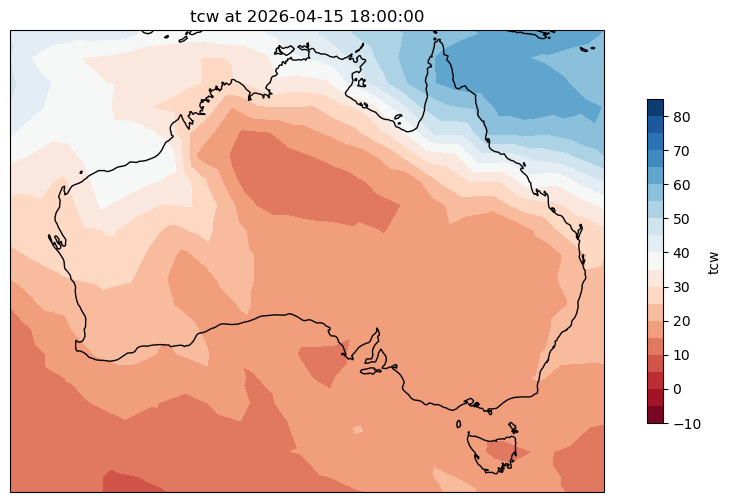

In [19]:
fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Limit the map to Australia
ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())

triangulation = tri.Triangulation(fix(longitudes), latitudes)

contour=ax.tricontourf(triangulation, values, levels=20, transform=ccrs.PlateCarree(), cmap="RdBu")
cbar = fig.colorbar(contour, ax=ax, orientation="vertical", shrink=0.7, label=variable)

plt.title("{} at {}".format(variable, state["date"]))
plt.show()

### Task 4.1: Plot the 2m temperature forecasts for the weekend?

The forecast is already calculated. Just make sure to select the correct state from the list and select the wanted parameter. The legend must be edited manually. Feel free to convert from Kelvin to Celcius.

### Plot a forecast time-series 

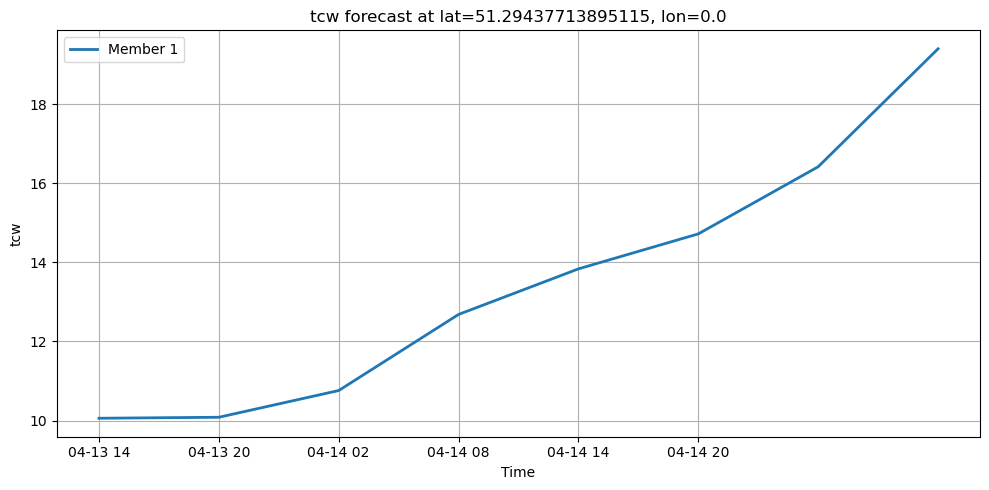

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

lat_target = 51.45
lon_target = -0.98
idx_nearest = find_nearest_point_index(latitudes, longitudes, lat_target, lon_target)

lead_times = range(len(forecast_states))

# Extract field for all members and times
values = np.array(
    [forecast_states[t]["fields"][variable][idx_nearest] for t in lead_times]
)

# Time axis
times = [forecast_states[t]["date"] for t in lead_times]
times = pd.to_datetime(times)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(times, values[:], linewidth=2, label=f"Member 1")

plt.title(f"{variable} forecast at lat={latitudes[idx_nearest]}, lon={longitudes[idx_nearest]}")
plt.xlabel("Time")
plt.ylabel(variable)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 4.2: Plot a 2m temperature forecast for the location of your city?

We have provided an example for the Reading, UK. Change to the location of the city you live in and and select the wanted parameter. 

Extra task: Try to calculate the forecast for more than 48 hours to have an idea of how warm it is going to be next week.

### Task 5: Explore out of sample data in the initial conditions

We have provided a way to get data which matches what the model was trained for, explore what happens if the data is incorrect 